# Mixture lab — what fraction of which district is a sensor reading?

The drift sweep is already an excitation experiment: each of its worlds moves **one**
district and holds everything else fixed. Stacking the worlds of a network gives a design
matrix with exactly one active column per world, so the mixture is identifiable at district
level from the real, settled simulation.

This is deliberately not the earlier Jacobian probe. Three differences, and each is why that
one did not cluster clients: the excitation is a real land-use conversion at realistic
magnitude rather than an infinitesimal nudge; it is measured after the new regime has
**settled**, at the actual operating point, not on a base topology; and it is taken on the
z-scored weekly profile, so a pure level change scores zero and what is measured is the
change of *signature* — the part that survives the FL scaler.

**Estimator.** For sensor `s` in the world where district `k` drifted,
`g[s,k] = <Δz_s, Δz_d(k)> / ||Δz_d(k)||²` — the OLS coefficient of the sensor's shape change
on that district's demand shape change. Stacked over `k` and normalised it is a simplex, so
"0.75 home / 0.25 District_X" is a literal reading.

**Noise floor.** A split-half null taken inside the drift-free `init` phase: the same `||Δz||`
between two disjoint halves of a stretch where nothing drifted, rescaled for sample size. A
gauge that does not clear it is not a mixed gauge, it is an unresponsive one — transit flow
or storage exchange — which is a different physical object.

**Outputs.** (1) a district×district dependence matrix measured from real drifts; (2) sensor
tiers — core, quantifiable transition, unusable; (3) whether core sets are contiguous, which
decides if placement can be stated geometrically or has to name elements.

## 0. Setup

In [1]:
%matplotlib inline
import sys, warnings, pathlib
import numpy as np, pandas as pd, matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 220, "display.max_columns", 80, "display.max_rows", 250)

HERE = pathlib.Path.cwd()
ROOT = next(p for p in [HERE, *HERE.parents] if (p / "conf" / "base").exists())
for p in (HERE, ROOT / "src", ROOT):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import landuse_world as lw
import signal_probe as sp
import landuse_sweep as ls
import mixture_probe as mp

SWEEP = ROOT / "data" / "09_experiments" / "landuse_sweep"
OUT = ROOT / "data" / "09_experiments" / "mixture"
OUT.mkdir(parents=True, exist_ok=True)
print(SWEEP, SWEEP.exists())

c:\Users\arthu\USPy\10_Mestrado\fedWater\data\09_experiments\landuse_sweep True


## 1. Point at the sweep's worlds

`CFG` must be **identical** to the one the sweep ran — cells are content-addressed, so any
difference changes the hashes and nothing is found. `BETA` picks one rung of the ladder;
§9 repeats the whole thing at a second rung to test whether the mixture is a property of the
topology or of the operating point.

In [5]:
# CFG = ls.SweepCfg(
#     networks=("ky7", "dtown"),
#     betas=(0.0, 0.15, 0.35, 0.6, 1.0),
#     districts=None,
#     to_land_use="industrial", to_income="low",
#     n_months=16, days_per_month=14, warmup_months=2,
#     max_neighbors_per_month=8, growth_chance=1.0,
#     drift_ramp_days=7, seasonality_scale=0.0)

CFG = ls.SweepCfg(
    networks=("ky7", "dtown", "graeme"),
    betas=(0.0, 0.15, 0.25, 0.35, 0.40, 0.50),
    districts=None,                    # None = every district of every network
    to_land_use="industrial", to_income="low",
    n_months=44, days_per_month=14, warmup_months=2,
    max_neighbors_per_month=8, growth_chance=1.0,
    drift_ramp_days=7, seasonality_scale=0.0)

NETWORK = "dtown"
BETA = 0.35

PROBES = mp.load_cells(NETWORK, BETA, CFG, ROOT, SWEEP)
print(f"{len(PROBES)} worlds:", sorted(PROBES))

5 worlds: ['District_A', 'District_B', 'District_C', 'District_D', 'District_E']


## 2. Settling — when is the new regime actually stable?

Your observation, made measurable: adherence between the best gauges and the district's
demand pattern only appears a few months *after* the last node switches.
`World.phases()` opens `final` at `last_switch + ramp_months`, which is too early if that
holds — the profile is still moving there, so an init/final contrast mixes the settled
regime with the tail of the transition.

The threshold is self-calibrating. A month's correlation to the terminal reference cannot
reach 1.0 even when the regime is stationary — weather, the month-level volume draw and the
crowd residual all cap it — and that cap is network- and horizon-specific. So the ceiling is
**measured** from the reference months themselves and "settled" means within a slack of it,
where the slack is at least twice the spread of those months. A fixed 0.99 reports
"never settled" on any world noisy enough to be realistic.

If settling is not immediate, what is settling is storage re-entering a duty cycle — the same
mechanism the lag search has been after. Worth reporting as a result, not absorbing as a
parameter.

In [6]:
H = mp.horizon_check(PROBES)
display(H)
if not H["ok"].all():
    print("\n>>> rerun the sweep with a longer n_months before going further.")

,drift_district,n_months,last_switch,settle_month,settled_from,settled_months,ok,need_n_months
0,District_A,44,24,22,23,21,True,26
1,District_B,44,12,10,11,33,True,14
2,District_C,44,15,13,14,30,True,17
3,District_D,44,20,18,19,25,True,22
4,District_E,44,29,23,24,20,True,27


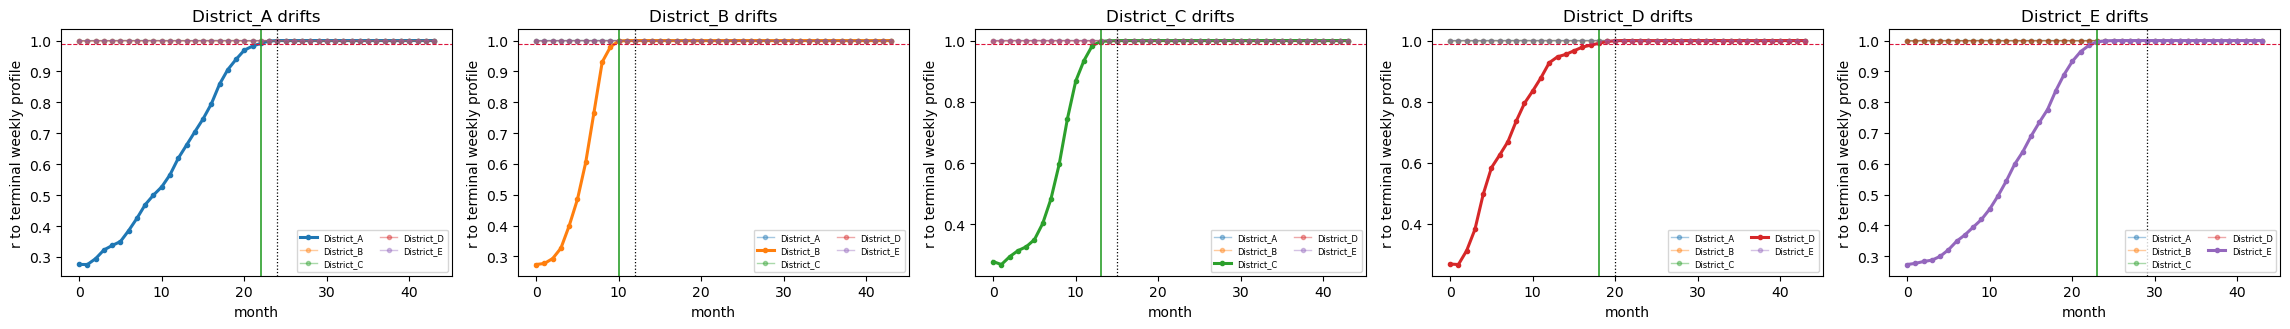

,district,drifted,settle_month,ceiling,threshold,r_min,r_at_first_final
0,District_A,True,22,1.0000,0.9900,0.2756,0.9999
1,District_B,False,0,0.9998,0.9898,0.9989,0.9994
2,District_C,False,0,0.9998,0.9898,0.9989,0.9994
3,District_D,False,0,0.9996,0.9896,0.9982,0.9994
4,District_E,False,0,1.0000,0.9900,0.9997,0.9999


In [7]:
tgts = sorted(PROBES)
fig, axes = plt.subplots(1, len(tgts), figsize=(4.6 * len(tgts), 3.4), squeeze=False)
for ax, d in zip(axes[0], tgts):
    mp.plot_settle(PROBES[d], ax=ax)
    ax.set_title(f"{d} drifts")
plt.tight_layout(); plt.show()

display(mp.settle_report(PROBES[tgts[0]]))

## 3. The noise floor

Two disjoint halves of the drift-free `init` phase, same statistic. Sample-size matching is
not optional: the null compares two half-init windows while the measurement compares the
whole init phase against a settled window many times longer, and a weekly profile's sampling
error falls as `1/sqrt(days)`. An unmatched null is inflated by that ratio and would condemn
most of the network as unresponsive purely because the null saw less data than the signal.

baseline months 0..1  |  settled months 23..43
null raw     median 2.936  p95 10.923
null matched median 1.537  p95 5.716  (scale 0.523)


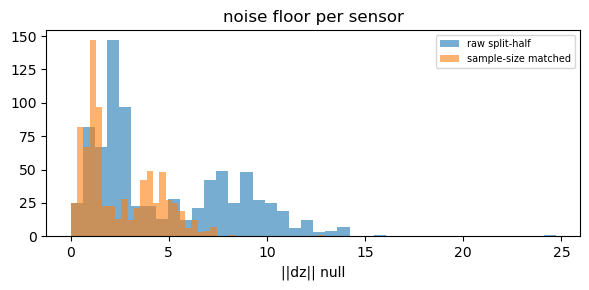

In [8]:
P0 = PROBES[tgts[0]]
cand = sp.candidates(P0)
lo0, hi0 = mp.baseline_window(P0)
lo1, hi1 = mp.settled_window(P0)
raw = mp.split_half_null(P0, cand)
matched = mp.split_half_null(P0, cand, windows=((lo0, hi0), (lo1, hi1)))
print(f"baseline months {lo0//P0.steps_month}..{hi0//P0.steps_month - 1}  |  "
      f"settled months {lo1//P0.steps_month}..{hi1//P0.steps_month - 1}")
print(f"null raw     median {np.median(raw):.3f}  p95 {np.quantile(raw, .95):.3f}")
print(f"null matched median {np.median(matched):.3f}  p95 {np.quantile(matched, .95):.3f}"
      f"  (scale {np.median(matched)/max(np.median(raw), 1e-9):.3f})")

fig, ax = plt.subplots(figsize=(6, 3))
for v, lab in ((raw, "raw split-half"), (matched, "sample-size matched")):
    ax.hist(v, bins=40, alpha=.6, label=lab)
ax.set(xlabel="||dz|| null", title="noise floor per sensor"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 4. Build the mixture

In [12]:
RES = mp.build_mixture(PROBES, null_factor=1.5, core_purity=0.85)
display(mp.mixture_diagnostics(RES))

  District_A: settled from month 23
  District_B: settled from month 11
  District_C: settled from month 14
  District_D: settled from month 19
  District_E: settled from month 24


,kind,n,unusable_%,n_live<=1_%,n_live_mean,purity_median,snr_median,neg_mass_%
0,flow,459,14.379,57.734,2.510,1.0,12.517,39.434
1,pressure,348,6.034,38.218,3.216,1.0,5.343,31.034


**Read `n_live<=1_%` before anything else.** If nearly every gauge cleared the null for
exactly one district, the "mixture" is 1.0 by construction and says nothing. Two very
different explanations — the null is set too high, or the worlds really are decoupled enough
that no gauge sees two districts — and the sweep below separates them. A tier split that
moves a lot between `null_factor` 1.5 and 5 is a result about the threshold, not about the
network.

,null_factor,core_purity,kind,core,transition,foreign,unusable,n_live_mean
0,0.5,0.85,flow,299,38,84,38,4.87
1,0.5,0.85,pressure,192,128,11,17,4.96
2,1.0,0.85,flow,300,37,84,38,4.00
3,1.0,0.85,pressure,192,128,11,17,4.94
4,1.5,0.85,flow,303,32,58,66,2.51
5,1.5,0.85,pressure,194,126,7,21,3.22
6,2.0,0.85,flow,304,32,54,69,2.03
7,2.0,0.85,pressure,194,126,0,28,2.99
8,3.0,0.85,flow,308,14,33,104,1.13
9,3.0,0.85,pressure,207,107,6,28,1.70


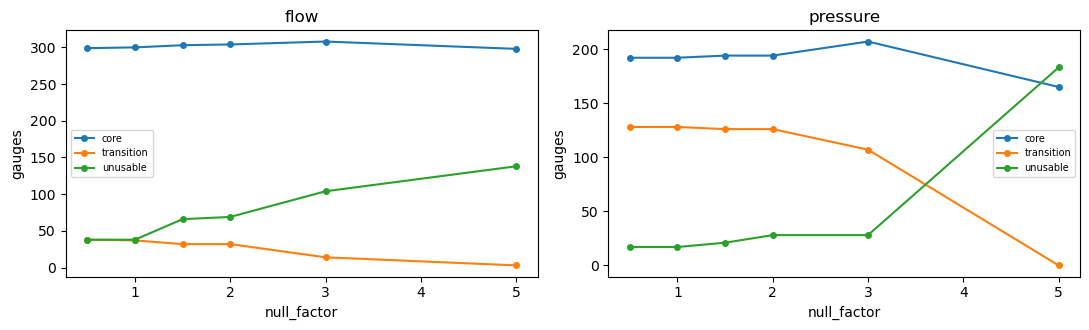

In [16]:
SENS = mp.tier_sensitivity(RES, factors=(0.5, 1.0, 1.5, 2.0, 3.0, 5.0))
display(SENS)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, kind in zip(axes, ("flow", "pressure")):
    d = SENS[SENS["kind"] == kind]
    for col in ("core", "transition", "unusable"):
        ax.plot(d["null_factor"], d[col], marker="o", ms=4, label=col)
    ax.set(xlabel="null_factor", ylabel="gauges", title=kind)
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

In [17]:
# Lock the threshold here once the sweep above has been read, then everything downstream
# uses this one object. `remix` recomputes from the stored gains — no re-solving.
NULL_FACTOR, CORE_PURITY = 1.5, 0.85
RES = mp.remix(RES, null_factor=NULL_FACTOR, core_purity=CORE_PURITY)
MIX = RES["mixture"]
display(MIX.groupby(["kind", "tier"]).size().rename("n").to_frame().T)

kind flow                             pressure                            
tier core foreign transition unusable     core foreign transition unusable
n     303      58         32       66      194       7        126       21

## 5. Tiers

`unusable` is **not** "noisy": it is a gauge whose signature did not move for any district's
drift. That is transit flow or storage exchange — a different physical object from a boundary
gauge reading two districts at once, and it should not share a bin with one.

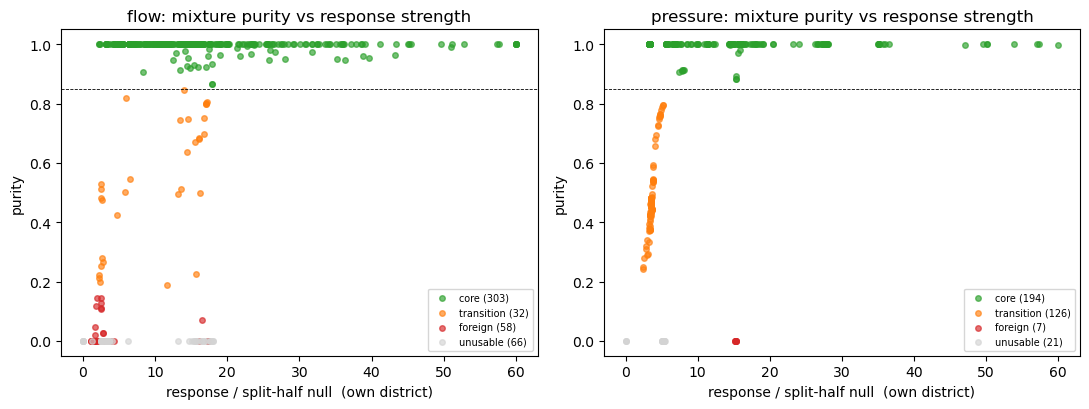

,district,kind,n,core,transition,foreign,unusable,readable_band,purity_max,purity_median,top_second
0,District_A,flow,135,132,0,1,2,0,1.0,1.000,
1,District_B,flow,54,35,0,0,19,0,1.0,1.000,
2,District_C,flow,59,37,17,5,0,16,1.0,0.945,District_B
3,District_D,flow,40,30,0,0,10,0,1.0,1.000,
4,District_E,flow,171,69,15,52,35,8,1.0,0.145,


,district,kind,n,core,transition,foreign,unusable,readable_band,purity_max,purity_median,top_second
0,District_A,pressure,93,72,0,0,21,0,1.000,1.000,
1,District_B,pressure,43,43,0,0,0,0,1.000,1.000,
2,District_C,pressure,49,42,0,7,0,0,1.000,1.000,
3,District_D,pressure,32,32,0,0,0,0,1.000,1.000,
4,District_E,pressure,131,5,126,0,0,108,0.915,0.464,District_D


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, kind in zip(axes, ("flow", "pressure")):
    mp.plot_purity(RES, kind, ax=ax)
plt.tight_layout(); plt.show()

display(mp.zones(RES, "flow"))
display(mp.zones(RES, "pressure"))

## 6. What each gauge is actually reading

The literal read-out. Each bar is one gauge's simplex over districts, ordered by purity.
`readable_band` in the zones table above counts the gauges whose mixture sits between 0.4 and
0.85 — pure enough to attribute, mixed enough to be informative about coupling. Those are the
sensors that can carry a *quantified* dependence statement rather than just a signal.

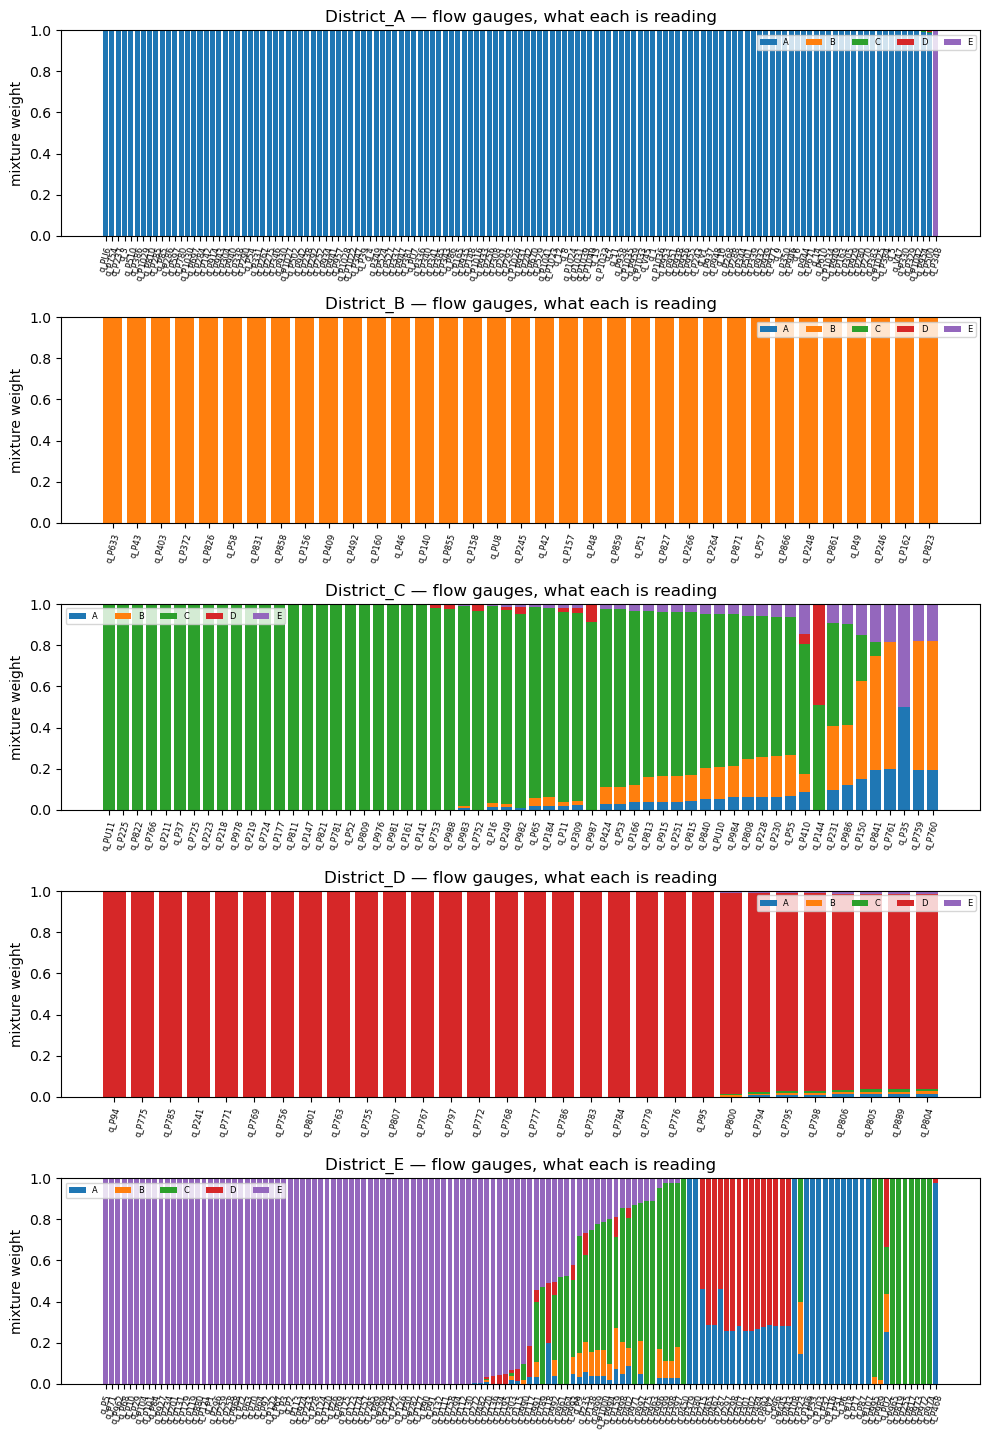

In [20]:
fig, axes = plt.subplots(len(tgts), 1, figsize=(10, 2.9 * len(tgts)))
for ax, d in zip(np.atleast_1d(axes), tgts):
    mp.plot_mixture_bars(RES, d, "flow", top=150, ax=ax)
plt.tight_layout(); plt.show()

In [21]:
cols = ["id", "home", "kind", "role", "tier", "purity", "second", "w_second",
        "snr_home", "n_live", "neg_mass"]
CORE = (MIX[MIX["tier"] == "core"].sort_values(["home", "kind", "snr_home"],
                                               ascending=[True, True, False])
        .groupby(["home", "kind"]).head(5))
display(CORE[cols].round(3))

TRANS = (MIX[(MIX["tier"] == "transition") & (MIX["w_second"] > 0.15)]
         .sort_values("snr_home", ascending=False).head(20))
display(TRANS[cols].round(3))

,id,home,kind,role,tier,purity,second,w_second,snr_home,n_live,neg_mass
799,q_PU6,District_A,flow,boundary,core,1.000,,0.000,8417.317,1,-0.000
478,q_P242,District_A,flow,internal,core,1.000,,0.000,71.185,5,0.003
741,q_P948,District_A,flow,internal,core,1.000,,0.000,70.979,5,0.004
730,q_P937,District_A,flow,internal,core,1.000,,0.000,70.438,1,-0.000
806,q_v1,District_A,flow,internal,core,1.000,,0.000,63.269,5,0.002
319,p_J81,District_A,pressure,internal,core,0.998,District_D,0.001,63.446,5,-0.000
163,p_J28,District_A,pressure,internal,core,1.000,,0.000,57.305,5,0.005
187,p_J32,District_A,pressure,internal,core,1.000,,0.000,57.065,5,0.005
167,p_J29,District_A,pressure,internal,core,1.000,,0.000,53.804,5,0.004
195,p_J33,District_A,pressure,internal,core,1.000,District_C,0.000,50.163,5,0.000


,id,home,kind,role,tier,purity,second,w_second,snr_home,n_live,neg_mass
692,q_P840,District_C,flow,internal,transition,0.752,District_B,0.152,16.823,5,0.005
675,q_P808,District_C,flow,internal,transition,0.696,District_B,0.185,16.808,5,0.005
470,q_P231,District_C,flow,internal,transition,0.498,District_B,0.311,16.271,5,0.008
469,q_P230,District_C,flow,internal,transition,0.682,District_B,0.196,16.036,5,0.007
467,q_P228,District_C,flow,internal,transition,0.685,District_B,0.194,16.035,5,0.007
434,q_P150,District_C,flow,internal,transition,0.224,District_B,0.475,15.635,5,0.005
608,q_P55,District_C,flow,internal,transition,0.670,District_B,0.202,15.552,5,0.005
793,q_PU10,District_C,flow,boundary,transition,0.748,District_B,0.152,14.541,5,0.005
430,q_P144,District_C,flow,internal,transition,0.510,District_D,0.490,13.578,5,0.123
776,q_P984,District_C,flow,internal,transition,0.743,District_B,0.152,13.390,5,0.022


## 7. Dependence ground truth

Rows: the observing district. Columns: whose drift is present in what that district's gauges
report. The diagonal is own-district signal; off-diagonal is influence arriving through
shared pipes.

This is dependence ground truth in the sense the project has been missing — measured from
real drifts at the real operating point, not inferred from the same observables the FL side
will be trained on. It is asymmetric by construction, because influence follows the supply
path.

One limit worth stating before it gets over-read: this is **influence, not causality** in the
time-series sense. It licenses "whose demand change reaches whose meters", not a directional
causal claim.

,use,kind,diag,offdiag,offdiag_max,ratio
0,core,flow,0.988,0.003,0.009,339.512
1,live,flow,0.988,0.003,0.009,339.512
2,all,flow,0.988,0.003,0.009,339.512


,kind,bin,n,share
0,flow,"[0.0, 0.15)",58,0.148
1,flow,"[0.15, 0.3)",8,0.020
2,flow,"[0.3, 0.5)",5,0.013
3,flow,"[0.5, 0.7)",10,0.025
4,flow,"[0.7, 0.85)",9,0.023
5,flow,"[0.85, 0.95)",15,0.038
6,flow,"[0.95, 1.001)",288,0.733
7,pressure,"[0.0, 0.15)",7,0.021
8,pressure,"[0.15, 0.3)",5,0.015
9,pressure,"[0.3, 0.5)",97,0.297


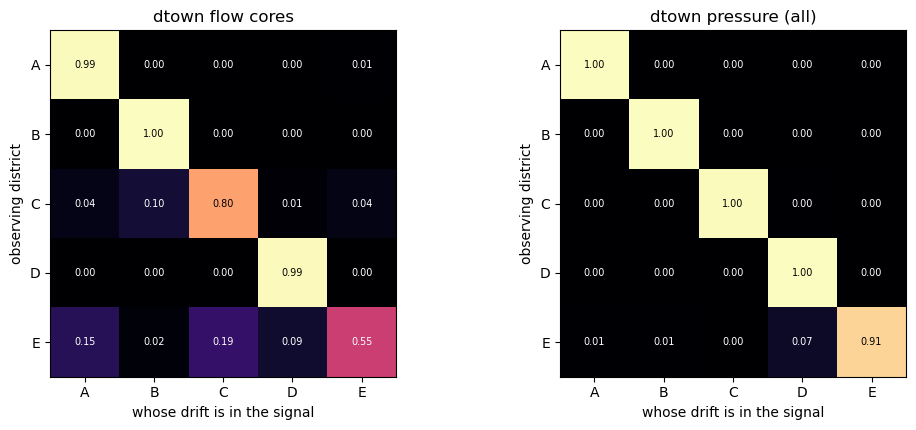

flow: diagonal 0.868 | off-diagonal 0.033


,District_A,District_B,District_C,District_D,District_E
District_A,0.992,0.000,0.000,0.000,0.008
District_B,0.000,1.000,0.000,0.000,0.000
District_C,0.043,0.099,0.803,0.014,0.042
District_D,0.002,0.003,0.003,0.989,0.003
District_E,0.153,0.019,0.186,0.088,0.554


In [22]:
A_flow = mp.dependence_matrix(mp.remix(RES, null_factor=1.5), "flow", top=None, use="live")
A_pres = mp.dependence_matrix(RES, kind="pressure", top=5, use="live")
display(mp.dependence_spread(RES, "flow"))
display(mp.purity_histogram(RES))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))
mp.plot_dependence(A_flow, ax=axes[0], title=f"{NETWORK} flow cores")
mp.plot_dependence(A_pres, ax=axes[1], title=f"{NETWORK} pressure (all)")
plt.tight_layout(); plt.show()

d = np.diag(A_flow.to_numpy())
off = A_flow.to_numpy()[~np.eye(len(A_flow), dtype=bool)]
print(f"flow: diagonal {np.nanmean(d):.3f} | off-diagonal {np.nanmean(off):.3f}")
display(A_flow.round(3))

## 8. Are the cores contiguous?

Measured, not assumed. Hydraulic influence follows the supply path rather than Euclidean
distance, so a core set has no a-priori reason to be a connected patch. If it is, a placement
rule can be stated geometrically; if it is not, placement has to name individual elements —
which is a weaker but still usable result.

,district,kind,n_core,components,largest_share
0,District_A,flow,132,1,1.000000
1,District_B,flow,35,3,0.583333
2,District_C,flow,37,3,0.477273
3,District_D,flow,30,1,1.000000
4,District_E,flow,69,8,0.317073
5,District_A,pressure,72,5,0.652778
6,District_B,pressure,43,1,1.000000
7,District_C,pressure,42,2,0.690476
8,District_D,pressure,32,1,1.000000
9,District_E,pressure,5,1,1.000000


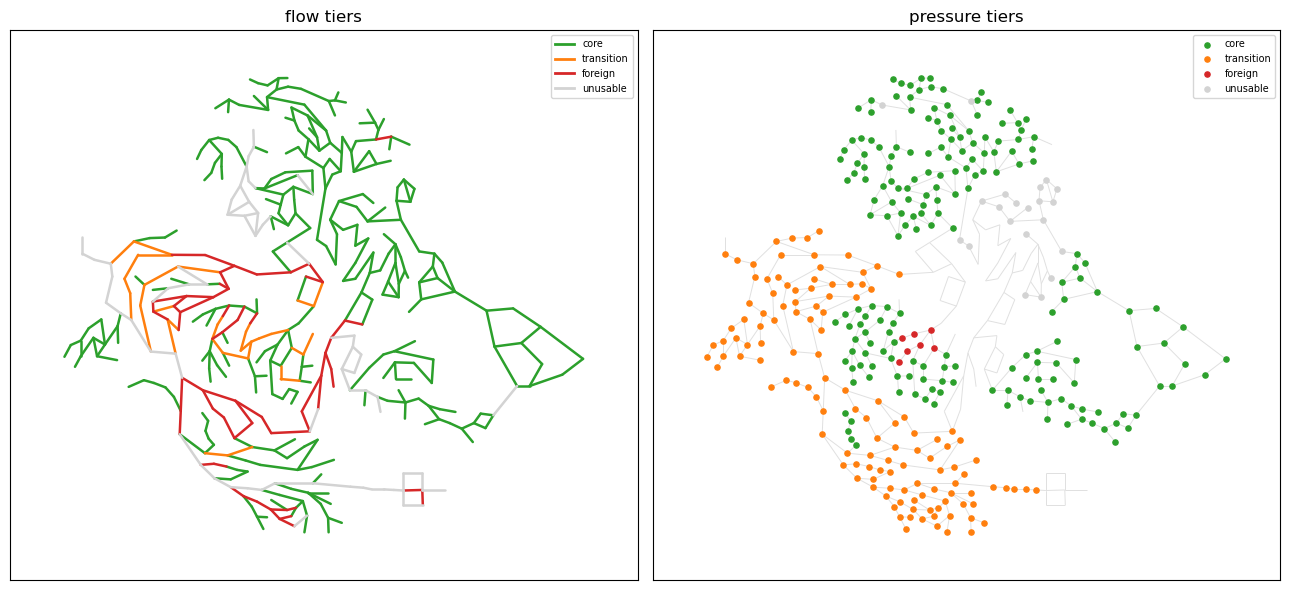

In [23]:
display(pd.concat([mp.core_connectivity(P0, RES, "flow"),
                   mp.core_connectivity(P0, RES, "pressure")], ignore_index=True))

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
mp.plot_tier_map(P0, RES, "flow", ax=axes[0])
mp.plot_tier_map(P0, RES, "pressure", ax=axes[1])
plt.tight_layout(); plt.show()

## 9. Does the mixture survive a change of drift strength?

Invariant weights mean the network is operating quasi-linearly and the mixture is a property
of the topology — transferable across scenarios, and reusable as ground truth. Weights that
move mean it is an operating-point statement and has to be re-measured per world, which is
the question the ky17 Spearman drop left open.

`tv` is total variation on the simplex: 0 is identical, 1 is disjoint.

In [25]:
for BETA_B in (0.0, 0.15, 0.25, 0.35, 0.40, 0.50):
    print(f"\n\n>>> beta={BETA_B} comparison")
    PROBES_B = mp.load_cells(NETWORK, BETA_B, CFG, ROOT, SWEEP)
    if len(PROBES_B) == len(PROBES):
        RES_B = mp.remix(mp.build_mixture(PROBES_B, verbose=False),
                        null_factor=NULL_FACTOR, core_purity=CORE_PURITY)
        display(mp.beta_stability(RES, RES_B, f"beta={BETA}", f"beta={BETA_B}"))
        display(mp.dependence_matrix(RES_B, "flow", top=5).round(3))
    else:
        print(f"beta={BETA_B} worlds incomplete ({len(PROBES_B)} of {len(PROBES)});"
            " run the sweep first")



>>> beta=0.0 comparison


,kind,n,purity_corr,tv_mean,tv_p90,tier_agree,compare
0,flow,459,0.847,0.156,0.500,0.782,beta=0.35 vs beta=0.0
1,pressure,348,0.728,0.201,0.495,0.882,beta=0.35 vs beta=0.0


,District_A,District_B,District_C,District_D,District_E
District_A,1.000,0.000,0.000,0.000,0.000
District_B,0.000,1.000,0.000,0.000,0.000
District_C,0.003,0.008,0.982,0.004,0.004
District_D,0.008,0.009,0.009,0.966,0.009
District_E,0.000,0.000,0.000,0.000,1.000




>>> beta=0.15 comparison


,kind,n,purity_corr,tv_mean,tv_p90,tier_agree,compare
0,flow,459,0.912,0.081,0.500,0.889,beta=0.35 vs beta=0.15
1,pressure,348,0.750,0.115,0.233,0.945,beta=0.35 vs beta=0.15


...

,District_A,District_B,District_C,District_D,District_E
District_A,1.000,0.000,0.000,0.000,0.000
District_B,0.000,1.000,0.000,0.000,0.000
District_C,0.006,0.009,0.977,0.003,0.006
District_D,0.008,0.009,0.009,0.965,0.009
District_E,0.000,0.000,0.000,0.000,1.000




>>> beta=0.4 comparison


,kind,n,purity_corr,tv_mean,tv_p90,tier_agree,compare
0,flow,459,0.902,0.120,0.500,0.837,beta=0.35 vs beta=0.4
1,pressure,348,0.828,0.074,0.177,0.945,beta=0.35 vs beta=0.4


,District_A,District_B,District_C,District_D,District_E
District_A,1.000,0.000,0.000,0.000,0.000
District_B,0.000,1.000,0.000,0.000,0.000
District_C,0.005,0.007,0.979,0.003,0.006
District_D,0.008,0.009,0.009,0.965,0.009
District_E,0.000,0.000,0.000,0.000,1.000




>>> beta=0.5 comparison
  missing world for District_A beta=0.5 (5c49c4d1)
  missing world for District_C beta=0.5 (68a07a8c)
  missing world for District_E beta=0.5 (359ab86b)
beta=0.5 worlds incomplete (2 of 5); run the sweep first


## 10. Both networks

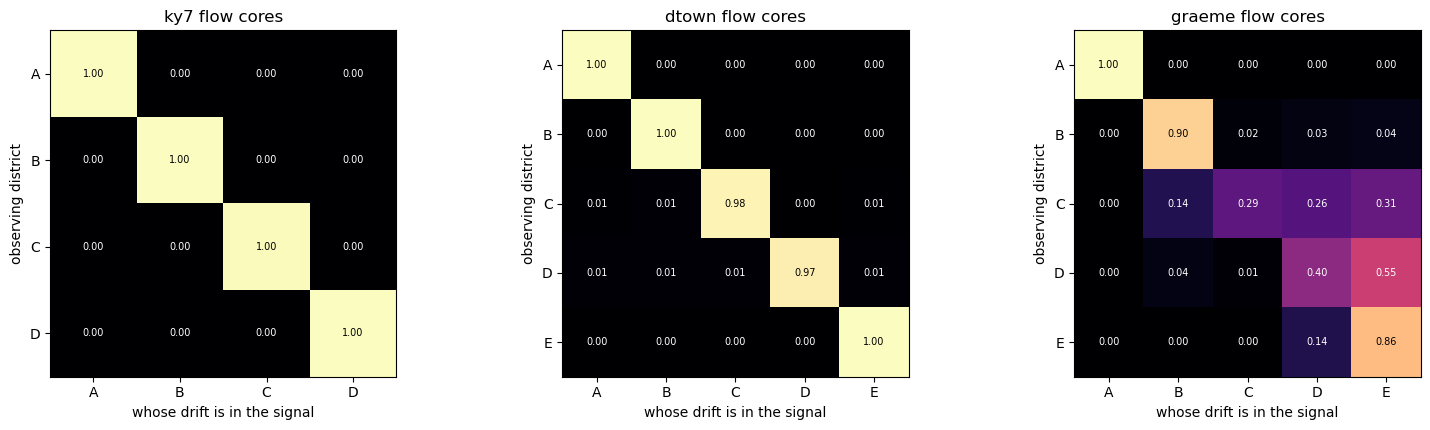

,network,diag,offdiag,core_flow,transition_flow,core_pressure,n_live_mean
0,ky7,0.999,0.000,428,72,301,2.619
1,dtown,0.988,0.003,303,32,194,2.814
2,graeme,0.691,0.077,71,70,0,3.739


In [ ]:
ALL = {}
for net in CFG.networks:
    pr = mp.load_cells(net, BETA, CFG, ROOT, SWEEP)
    if len(pr) < 2:
        print(f"{net}: only {len(pr)} worlds, skipping"); continue
    h = mp.horizon_check(pr)
    if not h["ok"].all():
        print(f"{net}: horizon too short, skipping"); continue
    ALL[net] = mp.remix(mp.build_mixture(pr, verbose=False),
                        null_factor=NULL_FACTOR, core_purity=CORE_PURITY)

fig, axes = plt.subplots(1, max(len(ALL), 1), figsize=(5.2 * max(len(ALL), 1), 4.4),
                         squeeze=False)
for ax, (net, r) in zip(axes[0], ALL.items()):
    mp.plot_dependence(mp.dependence_matrix(r, "flow", top=5), ax=ax,
                       title=f"{net} flow cores")
plt.tight_layout(); plt.show()

rows = []
for net, r in ALL.items():
    A = mp.dependence_matrix(r, "flow", top=5).to_numpy()
    m = r["mixture"]
    rows.append({"network": net,
                 "diag": float(np.nanmean(np.diag(A))),
                 "offdiag": float(np.nanmean(A[~np.eye(len(A), dtype=bool)])),
                 "core_flow": int(((m["tier"] == "core") & (m["kind"] == "flow")).sum()),
                 "transition_flow": int(((m["tier"] == "transition")
                                         & (m["kind"] == "flow")).sum()),
                 "core_pressure": int(((m["tier"] == "core")
                                       & (m["kind"] == "pressure")).sum()),
                 "n_live_mean": float(m["n_live"].mean())})
display(pd.DataFrame(rows).round(3))

## 11. Persist

In [48]:
for net, r in ALL.items():
    d = OUT / f"{net}_beta{BETA}"
    d.mkdir(parents=True, exist_ok=True)
    r["mixture"].to_parquet(d / "mixture.parquet", index=False)
    r["gains"].to_parquet(d / "gains.parquet", index=False)
    r["G"].to_csv(d / "gain_matrix.csv")
    mp.dependence_matrix(r, "flow", top=5).to_csv(d / "dependence_flow.csv")
    mp.dependence_matrix(r, "pressure", top=5, use="all").to_csv(d / "dependence_pressure.csv")
    mp.zones(r, "flow").to_csv(d / "zones_flow.csv", index=False)
    mp.mixture_diagnostics(r).to_csv(d / "diagnostics.csv", index=False)
    print(net, "->", d)

ky7 -> c:\Users\arthu\USPy\10_Mestrado\fedWater\data\09_experiments\mixture\ky7_beta0.35
dtown -> c:\Users\arthu\USPy\10_Mestrado\fedWater\data\09_experiments\mixture\dtown_beta0.35


## 12. Read-out

**Is the mixture real.** `n_live<=1_%` in §4 against the threshold sweep. High `n_live` that
survives `null_factor = 5` means gauges genuinely see several districts and the mixture is
measuring something. High `n_live` only at 1.5 means the threshold is manufacturing it.

**The dependence matrix.** §7 for one network, §10 for both. This is the artefact that did
not exist before: a measured, asymmetric, district-level influence matrix from real drifts.
The diagonal/off-diagonal ratio is the confounding problem in one number, and the KY7 vs
D-Town contrast is the claim that it is a network property rather than a method property.

**Tiers as placement zones, not a placement optimiser.** §5's `zones` says where a gauge can
be put and read: pure, quantifiably mixed, or unreadable. Using it to *avoid* the unreadable
region is safe; using it to maximise a downstream score would re-create the partition
problem one level down. Keep it a measurement reported alongside FL results, not a filter
applied before them.

**Contiguity.** §8 decides whether placement is statable as a rule or only as a list. A core
set in one component is a rule; four components is a list, and a list still works — it just
does not transfer to a network that has not been measured.

**Operating point.** §9. If `tier_agree` is high and `tv_mean` low across betas, the mixture
is topological and can be quoted once per network. If not, every result carries its beta.

**Pressure.** If pressure has almost no core gauges at any threshold and its dependence
matrix has no diagonal, then pressure cannot attribute a drift even where it detects one —
which is a stronger statement than "pressure is noisy" and a reason to drop it from the FL
feature set rather than carry it.

### Next
The transition gauges with `w_second > 0.15` in §6 are the most interesting rows in the whole
notebook: they are sensors reading a known, quantified blend of two districts. If the FL
prototypes built from them recover that blend, the federated pipeline is measuring dependence
rather than inheriting it — which is the thesis claim, and now it has a ground truth to be
checked against.